In [1]:
#Verify GPU
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

GPU Available: True
Device: Tesla T4


In [2]:
!pip install timm transformers scikit-learn

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
DATA_PATH = "/content/drive/MyDrive/finally_multimodel_IFND_is_cleaned.csv"
IMAGE_FOLDER = "/content/drive/MyDrive/final_images"

In [10]:
#import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

In [12]:
import pandas as pd

DATA_PATH = "/content/finally_multimodel_IFND_is_cleaned.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (29533, 4)
Columns: ['id', 'clean_text', 'image_path', 'Label']


,id,clean_text,image_path,Label
0,2,"WHO praises India's Aarogya Setu app, says it ...",final_images/2.jpg,True
1,3,"In Delhi, Deputy US Secretary of State Stephen...",final_images/3.jpg,True
2,4,LAC tensions: China's strategy behind delibera...,final_images/4.jpg,True
3,5,India has signed 250 documents on Space cooper...,final_images/5.jpg,True
4,6,Tamil Nadu chief minister's mother passes away...,final_images/6.jpg,True


In [13]:
print(df.shape)
print(df['Label'].unique())
print(df['Label'].value_counts())

(29533, 4)
[ True False]
Label
True     20063
False     9470
Name: count, dtype: int64


In [14]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Label'],
    random_state=42
)

In [15]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [16]:
class DeepfakeDataset(Dataset):
    def __init__(self, dataframe, image_folder, transform=None):
        self.df = dataframe
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_folder, os.path.basename(row['image_path']))

        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(row['Label'], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [17]:
train_dataset = DeepfakeDataset(train_df, IMAGE_FOLDER, train_transforms)
val_dataset = DeepfakeDataset(val_df, IMAGE_FOLDER, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)

# Freeze first layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


In [19]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

In [20]:
def train_model(model, train_loader, val_loader, epochs=10):
    best_auc = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss/len(train_loader):.4f}")

    return model

In [21]:
model = train_model(model, train_loader, val_loader, epochs=10)

Epoch 1/10 - Train Loss: 0.5896
Epoch 2/10 - Train Loss: 0.5692
Epoch 3/10 - Train Loss: 0.5621
Epoch 4/10 - Train Loss: 0.5585
Epoch 5/10 - Train Loss: 0.5582
Epoch 6/10 - Train Loss: 0.5542
Epoch 7/10 - Train Loss: 0.5520
Epoch 8/10 - Train Loss: 0.5494
Epoch 9/10 - Train Loss: 0.5493
Epoch 10/10 - Train Loss: 0.5471


In [22]:
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_preds = [1 if p > 0.5 else 0 for p in all_probs]

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

Accuracy: 0.7455561198577958
Precision: 0.7428405572755418
Recall: 0.956640917019686
F1 Score: 0.836292342882039
ROC AUC: 0.6768904571231144


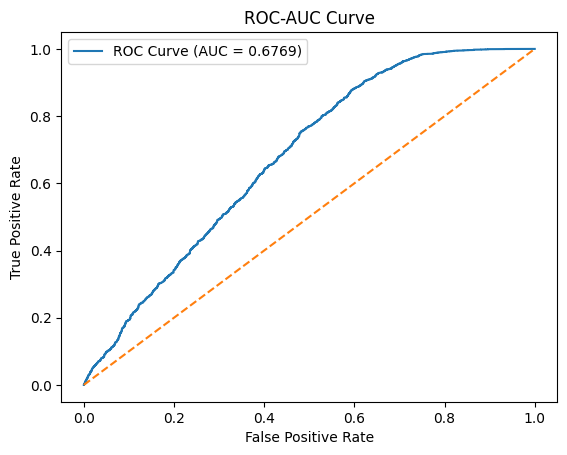

In [23]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

In [24]:
MODEL_PATH = "/content/drive/MyDrive/resnet50_deepfake.pth"
torch.save(model.state_dict(), MODEL_PATH)

print("Model Saved Successfully!")

Model Saved Successfully!


MULTIMODAL


In [1]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU Available: False
Device: CPU


In [2]:
!pip install transformers timm scikit-learn

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [5]:
DATA_PATH = "/content/finally_multimodel_IFND_is_cleaned.csv"

df = pd.read_csv(DATA_PATH)

# Fix labels
df['Label'] = df['Label'].astype(str).str.strip().str.lower()
df['Label'] = df['Label'].map({'true': 1, 'false': 0})

print(df.shape)
print(df['Label'].value_counts())

(29533, 4)
Label
1    20063
0     9470
Name: count, dtype: int64


In [6]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Label'],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 23626
Val: 5907


In [7]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [8]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
DATA_PATH = "/content/drive/MyDrive/finally_multimodel_IFND_is_cleaned.csv"
IMAGE_FOLDER = "/content/drive/MyDrive/final_images"

In [11]:
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, root_path, transform=None, max_len=128):
        self.df = dataframe.reset_index(drop=True)
        self.root_path = root_path
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        img_path = os.path.join(IMAGE_FOLDER, row['image_path'].split('/')[-1])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Text
        encoding = tokenizer(
            row['clean_text'],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        label = torch.tensor(row['Label'], dtype=torch.float32)

        return image, input_ids, attention_mask, label

In [12]:
train_loader = DataLoader(
    MultimodalDataset(train_df, "/content", train_transforms),
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    MultimodalDataset(val_df, "/content", val_transforms),
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [13]:
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, transform=None, max_len=128):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Get only image filename
        img_name = row['image_path'].split('/')[-1]
        img_path = os.path.join(IMAGE_FOLDER, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        encoding = tokenizer(
            row['clean_text'],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        label = torch.tensor(row['Label'], dtype=torch.float32)

        return image, input_ids, attention_mask, label

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalModel().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=2e-4)

NameError: name 'MultimodalModel' is not defined

In [18]:
def train_model(model, train_loader, val_loader, epochs=5):
    best_auc = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, input_ids, attention_mask, labels in train_loader:
            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images, input_ids, attention_mask).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        print(f"Epoch {epoch+1} - Train Loss: {train_loss/len(train_loader):.4f}")

    return model

In [19]:
model = train_model(model, train_loader, val_loader, epochs=5)

NameError: name 'model' is not defined

In [ ]:
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for images, input_ids, attention_mask, labels in val_loader:
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(images, input_ids, attention_mask).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_preds = [1 if p > 0.5 else 0 for p in all_probs]

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print("Accuracy:", accuracy)
print("F1:", f1)
print("ROC AUC:", roc_auc)

In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
torch.save(model.state_dict(), "/content/multimodal_model.pth")